## Import Libraries and GPU Setup

In [1]:
import os
import json
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


Using device: mps


## Model Configuration


In [2]:
# Dataset configuration
DATA_PATH = "../../data/indoorAir2.csv"
SPLIT_MODE = "chronological_by_station"
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RESAMPLE_FREQ = "15min"
MAX_FILL_STEPS = 2
SEGMENT_COLUMN = "_continuous_segment_id"
EXCLUDED_STATIONS = [6]

# Feature and target configuration
FEATURE_COLUMNS = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend",
]

TARGET_FEATURE = "scd41_co2"
TARGET_LABELS = {
    "scd41_co2": "CO2",
    "ens160_aqi": "AQI",
    "ens160_tvoc": "TVOC",
    "bme688_gas_resistance": "Gas Resistance",
    "bme688_pressure": "Pressure",
    "scd41_temperature": "Temperature",
    "scd41_humidity": "Humidity",
}

def get_target_label(target_feature):
    return TARGET_LABELS.get(
        target_feature,
        target_feature.replace("_", " ").title()
    )

# Forecast configuration
# 15-min data: 192 input steps = 2 days, 24 output steps = 6 hours ahead.
SEQ_LENGTH = 192
OUTPUT_LENGTH = 24
BATCH_SIZE = 32
EPOCHS = 10

# Wavelet/scattering configuration
# Keep False for the faster baseline Transformer run. Set True for wavelet features.
USE_SCATTERING = False
SCATTERING_J = 3
SCATTERING_Q = 8
N_SCATTERING_FEATURES = 16

# Transformer configuration
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
DIM_FEEDFORWARD = 512
DROPOUT = 0.28
POOLING_METHOD = "attention"
RESIDUAL_FORECAST = True
CLAMP_OUTPUT = True
TREND_LOOKBACK = 64
TREND_DAMPING = 0.30
RESIDUAL_SCALE = 0.18

# Training configuration
LEARNING_RATE = 0.00007
WEIGHT_DECAY = 7e-4
HUBER_DELTA = 0.03
HORIZON_LOSS_WEIGHT_END = 2.6
DELTA_LOSS_WEIGHT = 0.15
EARLY_STOPPING_PATIENCE = 12
MIN_DELTA = 1e-6
SCHEDULER_PATIENCE = 4
SCHEDULER_FACTOR = 0.5
GRAD_CLIP_MAX_NORM = 1.0

# Plotting, explainability, uncertainty, and output configuration
# Use an integer such as 2000 for limited plots, or None for all timesteps.
PLOT_SIZE = 2000
EXPLAINABILITY_BATCHES = 8
MC_DROPOUT_RUNS = 30
UNCERTAINTY_BATCHES = 8
RESULTS_ROOT = "../../Transformer_Results"
EXPERIMENT_NAME = (
    f"Transformer_IL{SEQ_LENGTH}_OL{OUTPUT_LENGTH}_"
    f"E{EPOCHS}_BS{BATCH_SIZE}_LR{LEARNING_RATE}_"
    f"DR{DROPOUT}_GF{MAX_FILL_STEPS}_SPLIT{SPLIT_MODE}_"
    f"ATTNPOOL_TRENDLOSS_WEND{HORIZON_LOSS_WEIGHT_END}_"
    f"SWT{int(USE_SCATTERING)}_"
    f"SWJ{SCATTERING_J if USE_SCATTERING else 0}_"
    f"SWQ{SCATTERING_Q if USE_SCATTERING else 0}_"
    f"SWF{N_SCATTERING_FEATURES if USE_SCATTERING else 0}"
)
RESULTS_DIR = os.path.join(RESULTS_ROOT, EXPERIMENT_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)

target_label = get_target_label(TARGET_FEATURE)

print("Results folder:", RESULTS_DIR)
print("Wavelet scattering enabled:", USE_SCATTERING)
print("Long-horizon tuning: attention pooling + trend residual + horizon-weighted loss")


Results folder: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0
Wavelet scattering enabled: False
Long-horizon tuning: attention pooling + trend residual + horizon-weighted loss


## Device Setup

## Load and Sort Dataset

In [3]:
df = pd.read_csv(DATA_PATH)
raw_shape = df.shape

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

if EXCLUDED_STATIONS:
    df = df[~df["station_id"].isin(EXCLUDED_STATIONS)].copy()

df = df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print("Raw shape              :", raw_shape)
print("After station filtering:", df.shape)
print("Excluded stations      :", EXCLUDED_STATIONS)
df.head()


Raw shape              : (1924653, 21)
After station filtering: (1924649, 21)
Excluded stations      : [6]


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cyclic Time Feature Engineering

In [4]:
station_counts = df.groupby("station_id").size().rename("rows")
print("Rows per station after filtering:")
print(station_counts)

hour = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60
dayofweek = df["timestamp"].dt.dayofweek

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)
df["is_weekend"] = dayofweek.isin([5, 6]).astype(int)

feature_df = df[
    FEATURE_COLUMNS + ["timestamp", "station_id"]
].copy()

print("Feature Data Shape:", feature_df.shape)
feature_df.head()


Rows per station after filtering:
station_id
1    586547
2    174666
3    361836
4    549339
5    252261
Name: rows, dtype: int64
Feature Data Shape: (1924649, 14)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,timestamp,station_id
0,1,32,NaN,NaN,22.951857,36.897277,488.0,-0.962455,-0.271440,0.974928,-0.222521,0,2024-11-13 16:57:56,1
1,1,30,NaN,NaN,22.335011,38.185119,485.0,-0.963630,-0.267238,0.974928,-0.222521,0,2024-11-13 16:58:57,1
2,1,43,NaN,NaN,22.353704,38.400268,477.0,-0.964787,-0.263031,0.974928,-0.222521,0,2024-11-13 16:59:59,1
3,1,26,NaN,NaN,22.417792,38.269042,474.0,-0.967046,-0.254602,0.974928,-0.222521,0,2024-11-13 17:01:03,1
4,1,31,NaN,NaN,22.556649,37.971496,473.0,-0.968148,-0.250380,0.974928,-0.222521,0,2024-11-13 17:02:05,1


## Chronological Train Validation Test Split Per Station


In [5]:
def split_station_chronologically(station_data):
    station_data = station_data.sort_values("timestamp").copy()
    n_rows = len(station_data)
    train_end = int(n_rows * TRAIN_RATIO)
    val_end = train_end + int(n_rows * VAL_RATIO)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )


train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_chronologically(
        station_data
    )
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

    print()
    print(f"Station {station_id}")
    print("Train      :", station_train["timestamp"].min(), "->", station_train["timestamp"].max(), station_train.shape)
    print("Validation :", station_val["timestamp"].min(), "->", station_val["timestamp"].max(), station_val.shape)
    print("Test       :", station_test["timestamp"].min(), "->", station_test["timestamp"].max(), station_test.shape)

train_df = pd.concat(train_parts).sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

total_rows = len(feature_df)
print()
print("Split mode       :", SPLIT_MODE)
print("Train Shape      :", train_df.shape, f"({len(train_df) / total_rows * 100:.2f}%)")
print("Validation Shape :", val_df.shape, f"({len(val_df) / total_rows * 100:.2f}%)")
print("Test Shape       :", test_df.shape, f"({len(test_df) / total_rows * 100:.2f}%)")

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("validation"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print()
print("Rows per station:")
print(split_counts)



Station 1
Train      : 2024-11-13 16:57:56 -> 2025-12-10 22:21:26 (410582, 14)
Validation : 2025-12-10 22:22:28 -> 2026-02-15 03:49:55 (87982, 14)
Test       : 2026-02-15 03:50:55 -> 2026-04-22 13:10:59 (87983, 14)

Station 2
Train      : 2024-12-20 12:31:37 -> 2025-05-30 08:44:22 (122266, 14)
Validation : 2025-05-30 08:45:42 -> 2025-06-19 10:47:54 (26199, 14)
Test       : 2025-06-19 10:49:00 -> 2025-07-10 09:53:06 (26201, 14)

Station 3
Train      : 2025-01-17 12:39:25 -> 2026-01-30 22:34:02 (253285, 14)
Validation : 2026-01-30 22:35:03 -> 2026-03-14 05:16:43 (54275, 14)
Test       : 2026-03-14 05:17:45 -> 2026-04-22 13:10:52 (54276, 14)

Station 4
Train      : 2025-01-21 18:39:02 -> 2025-12-18 17:41:03 (384537, 14)
Validation : 2025-12-18 17:42:04 -> 2026-02-21 23:49:43 (82400, 14)
Test       : 2026-02-21 23:50:43 -> 2026-04-22 13:10:38 (82402, 14)

Station 5
Train      : 2025-02-14 12:38:38 -> 2025-06-30 09:27:36 (176582, 14)
Validation : 2025-06-30 09:28:39 -> 2025-07-30 05:09:10 

## Prepare Timestamp Index

Timestamps are ordered separately for each station before resampling.


In [6]:
def prepare_timestamp_index(data):
    data = data.copy()
    data["timestamp"] = pd.to_datetime(data["timestamp"])
    return data.sort_values(
        ["station_id", "timestamp"]
    ).set_index("timestamp")


train_df = prepare_timestamp_index(train_df)
val_df = prepare_timestamp_index(val_df)
test_df = prepare_timestamp_index(test_df)

print("Timestamp index prepared separately for every station.")


Timestamp index prepared separately for every station.


## Resample each station separately

In [7]:
def resample_station_data(data, freq=RESAMPLE_FREQ):
    station_data_list = []

    for station in data["station_id"].unique():
        station_df = data[data["station_id"] == station].copy()
        station_df = station_df.sort_index()
        station_df = station_df.resample(freq).mean()
        station_df["station_id"] = station
        station_data_list.append(station_df)

    return pd.concat(station_data_list)


train_df = resample_station_data(train_df)
val_df = resample_station_data(val_df)
test_df = resample_station_data(test_df)

print("After Resampling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)


After Resampling

Train Shape      : (134242, 13)
Validation Shape : (21478, 13)
Test Shape       : (31178, 13)


## Limited Missing-Value Filling and Long-Gap Segmentation

Only short input-feature gaps are filled. Missing CO2 targets and longer gaps
create continuous-segment boundaries that sequence windows cannot cross.


In [8]:
def fill_short_feature_gaps(series, max_fill_steps):
    if max_fill_steps <= 0 or not series.isna().any():
        return series

    missing = series.isna()
    run_ids = missing.ne(missing.shift()).cumsum()
    run_lengths = missing.groupby(run_ids).transform("sum")
    short_gap_mask = missing & (run_lengths <= max_fill_steps)

    nearby_values = series.interpolate(
        method="time",
        limit_direction="both",
    )
    filled = series.copy()
    filled.loc[short_gap_mask] = nearby_values.loc[short_gap_mask]
    return filled


def handle_missing_values_and_segments(data):
    cleaned_stations = []
    expected_interval = pd.Timedelta(RESAMPLE_FREQ)

    for station_id, station_df in data.groupby("station_id", sort=True):
        station_df = station_df.sort_index().copy()

        # Never create artificial target CO2 values.
        station_df = station_df.dropna(subset=[TARGET_FEATURE])

        input_columns = [
            column for column in FEATURE_COLUMNS
            if column != TARGET_FEATURE and column in station_df.columns
        ]
        station_df[input_columns] = station_df[input_columns].apply(
            fill_short_feature_gaps,
            max_fill_steps=MAX_FILL_STEPS,
        )

        # Long missing runs remain missing and are removed.
        station_df = station_df.dropna(subset=FEATURE_COLUMNS)

        timestamp_difference = station_df.index.to_series().diff()
        new_segment = timestamp_difference > expected_interval
        station_df[SEGMENT_COLUMN] = new_segment.cumsum().astype(int)

        print(f"\nStation {station_id}")
        print("Rows after limited filling:", len(station_df))
        print("Long gaps detected:", int(new_segment.sum()))
        print("Continuous segments:", station_df[SEGMENT_COLUMN].nunique())
        print("Largest timestamp difference:", timestamp_difference.max())

        cleaned_stations.append(station_df)

    if not cleaned_stations:
        raise ValueError("No data remains after missing-value handling.")

    return pd.concat(cleaned_stations).sort_values(
        ["station_id", SEGMENT_COLUMN]
    )


train_df = handle_missing_values_and_segments(train_df)
val_df = handle_missing_values_and_segments(val_df)
test_df = handle_missing_values_and_segments(test_df)

print("\nMaximum filled feature gap:", pd.Timedelta(RESAMPLE_FREQ) * MAX_FILL_STEPS)
print("Sequences crossing long gaps: disabled")



Station 1
Rows after limited filling: 25972
Long gaps detected: 23
Continuous segments: 24
Largest timestamp difference: 30 days 23:30:00

Station 2
Rows after limited filling: 8829
Long gaps detected: 9
Continuous segments: 10
Largest timestamp difference: 32 days 02:30:00

Station 3
Rows after limited filling: 17691
Long gaps detected: 18
Continuous segments: 19
Largest timestamp difference: 138 days 14:30:00

Station 4
Rows after limited filling: 27520
Long gaps detected: 17
Continuous segments: 18
Largest timestamp difference: 28 days 20:45:00

Station 5
Rows after limited filling: 12853
Long gaps detected: 4
Continuous segments: 5
Largest timestamp difference: 1 days 19:30:00

Station 1
Rows after limited filling: 6082
Long gaps detected: 1
Continuous segments: 2
Largest timestamp difference: 2 days 21:30:00

Station 2
Rows after limited filling: 1926
Long gaps detected: 1
Continuous segments: 2
Largest timestamp difference: 0 days 01:00:00

Station 3
Rows after limited filling: 

## Feature Scaling and Normalization

In [9]:
feature_columns = [
    column for column in FEATURE_COLUMNS
    if column in train_df.columns
]

scaler = MinMaxScaler()
scaler.fit(train_df[feature_columns])


def scale_dataframe(data):
    scaled = data.copy()
    scaled[feature_columns] = scaler.transform(data[feature_columns])
    return scaled


train_scaled_df = scale_dataframe(train_df)
val_scaled_df = scale_dataframe(val_df)
test_scaled_df = scale_dataframe(test_df)

# Arrays remain available for the existing wavelet demonstration cells.
train_scaled = train_scaled_df[feature_columns].to_numpy()
val_scaled = val_scaled_df[feature_columns].to_numpy()
test_scaled = test_scaled_df[feature_columns].to_numpy()

print("Train Scaled Shape      :", train_scaled.shape)
print("Validation Scaled Shape :", val_scaled.shape)
print("Test Scaled Shape       :", test_scaled.shape)
print("Scaler fitted only on training data.")


Train Scaled Shape      : (92865, 12)
Validation Scaled Shape : (20159, 12)
Test Scaled Shape       : (20069, 12)
Scaler fitted only on training data.


In [10]:
target_label = get_target_label(TARGET_FEATURE)
target_index = feature_columns.index(TARGET_FEATURE)

print("Target Feature:", TARGET_FEATURE)
print("Target Index  :", target_index)
print("Input Length  :", SEQ_LENGTH)
print("Output Length :", OUTPUT_LENGTH)


Target Feature: scd41_co2
Target Index  : 6
Input Length  : 192
Output Length : 24


## Initialize Wavelet Scattering Transform

The Wavelet Scattering Transform was initialized using the Kymatio library. The transform will be applied to the most important environmental variables identified through feature ablation analysis, namely temperature and CO₂, to generate additional static features for Transformer forecasting.

In [11]:
if USE_SCATTERING:
    from kymatio.scattering1d.frontend.numpy_frontend import ScatteringNumPy1D

    scattering = ScatteringNumPy1D(
        J=SCATTERING_J,
        shape=SEQ_LENGTH,
        Q=SCATTERING_Q,
    )
    print("Scattering initialized for model features")
else:
    scattering = None
    print("Scattering disabled. Set USE_SCATTERING = True in the config cell to enable wavelet features.")


Scattering disabled. Set USE_SCATTERING = True in the config cell to enable wavelet features.


#  Verification of Scattering Feature Extraction

Before applying the Wavelet Scattering Transform to the complete dataset, a single temperature sequence was selected to verify that the transform was functioning correctly and producing valid scattering coefficients.

In [12]:
# Temperature feature index

temp_idx = feature_columns.index(
    "scd41_temperature"
)

# First sample from scaled training data

sample_signal = train_scaled[
    :SEQ_LENGTH,
    temp_idx
]

print("Signal Shape:")
print(sample_signal.shape)

Signal Shape:
(192,)


In [13]:
if USE_SCATTERING:
    sample_scattering = scattering(sample_signal)
    print("Scattering Shape:")
    print(sample_scattering.shape)
else:
    sample_scattering = None
    print("Scattering verification skipped because USE_SCATTERING = False")


Scattering verification skipped because USE_SCATTERING = False


#  Generation of Scattering Features

Wavelet Scattering coefficients were extracted from the temperature and CO₂ signals. To obtain compact static representations, summary statistics were computed from the scattering coefficients and used as additional features for forecasting.

In [14]:
temp_idx = feature_columns.index("scd41_temperature")
co2_idx = feature_columns.index("scd41_co2")

sample_temp = train_scaled[:SEQ_LENGTH, temp_idx]
sample_co2 = train_scaled[:SEQ_LENGTH, co2_idx]

if USE_SCATTERING:
    temp_scattering = scattering(sample_temp)
    co2_scattering = scattering(sample_co2)

    print("Temperature Scattering Shape:", temp_scattering.shape)
    print("CO2 Scattering Shape:", co2_scattering.shape)
else:
    temp_scattering = None
    co2_scattering = None
    print("Wavelet feature generation skipped because USE_SCATTERING = False")


Wavelet feature generation skipped because USE_SCATTERING = False


#  Extraction of Statistical Scattering Features

To reduce dimensionality, statistical summaries were computed from the scattering coefficients. The mean, standard deviation, maximum, and minimum values were extracted and used as static wavelet features.

In [15]:
if USE_SCATTERING:
    temp_features = [
        np.mean(temp_scattering),
        np.std(temp_scattering),
        np.max(temp_scattering),
        np.min(temp_scattering),
    ]

    co2_features = [
        np.mean(co2_scattering),
        np.std(co2_scattering),
        np.max(co2_scattering),
        np.min(co2_scattering),
    ]

    wavelet_features = np.concatenate([
        temp_features,
        co2_features,
    ])

    print("Wavelet Feature Vector Shape:")
    print(wavelet_features.shape)
else:
    wavelet_features = np.array([])
    print("No wavelet feature vector created because USE_SCATTERING = False")


No wavelet feature vector created because USE_SCATTERING = False


In [16]:
print(train_df.columns.tolist())

['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'station_id', '_continuous_segment_id']


# Gap-Aware Sequence Generation

The original sliding-window dataset is retained, but windows are now generated
separately for every station and continuous segment.


In [17]:
from torch.utils.data import Dataset


def get_scattering_feature_names(n_scattering_features):
    return [
        f"scatter_co2_{index + 1}"
        for index in range(n_scattering_features)
    ]


def compute_static_scattering_features(
    signal_window,
    scattering_transform,
    n_scattering_features,
):
    signal_window = np.asarray(signal_window, dtype=np.float32)
    scattering_coefficients = scattering_transform(signal_window)
    scattering_coefficients = np.asarray(scattering_coefficients)

    if scattering_coefficients.ndim == 2:
        static_vector = scattering_coefficients.mean(axis=1)
    else:
        static_vector = scattering_coefficients.reshape(-1)

    static_vector = static_vector[:n_scattering_features]

    if len(static_vector) < n_scattering_features:
        static_vector = np.pad(
            static_vector,
            (0, n_scattering_features - len(static_vector)),
            mode="constant",
        )

    return static_vector.astype(np.float32)


class TimeSeriesDataset(Dataset):
    def __init__(
        self,
        data,
        feature_columns,
        seq_length,
        output_length,
        target_index,
        use_scattering=False,
        scattering_transform=None,
        n_scattering_features=0,
    ):
        if use_scattering and scattering_transform is None:
            raise ValueError(
                "scattering_transform must be provided when "
                "USE_SCATTERING = True"
            )

        self.segments = []
        self.samples = []
        self.seq_length = seq_length
        self.output_length = output_length
        self.target_index = target_index
        self.use_scattering = use_scattering
        self.scattering_transform = scattering_transform
        self.n_scattering_features = n_scattering_features if use_scattering else 0
        self.input_dim = len(feature_columns) + self.n_scattering_features
        self.scattering_cache = {}

        grouped = data.groupby(
            ["station_id", SEGMENT_COLUMN],
            sort=True,
        )

        for (station_id, segment_id), segment in grouped:
            values = segment.sort_index()[feature_columns].to_numpy(
                dtype=np.float32
            )
            window_length = seq_length + output_length

            if len(values) < window_length:
                continue

            segment_index = len(self.segments)
            self.segments.append(values)

            for start in range(len(values) - window_length + 1):
                self.samples.append((segment_index, start))

        if not self.samples:
            raise ValueError("No continuous sequences were created.")

    def __len__(self):
        return len(self.samples)

    def _get_scattering_features(self, segment_index, start, X):
        cache_key = (segment_index, start)
        if cache_key not in self.scattering_cache:
            co2_window = X[:, self.target_index]
            self.scattering_cache[cache_key] = compute_static_scattering_features(
                co2_window,
                self.scattering_transform,
                self.n_scattering_features,
            )

        static_vector = self.scattering_cache[cache_key]
        return np.repeat(
            static_vector.reshape(1, -1),
            self.seq_length,
            axis=0,
        )

    def __getitem__(self, idx):
        segment_index, start = self.samples[idx]
        values = self.segments[segment_index]
        target_start = start + self.seq_length
        target_end = target_start + self.output_length

        X = values[start:target_start]
        y = values[
            target_start:target_end,
            self.target_index,
        ]

        if self.use_scattering:
            repeated_scattering = self._get_scattering_features(
                segment_index,
                start,
                X,
            )
            X = np.concatenate([X, repeated_scattering], axis=1)

        return torch.from_numpy(X.astype(np.float32)), torch.from_numpy(y.astype(np.float32))


In [18]:
train_dataset = TimeSeriesDataset(
    train_scaled_df,
    feature_columns,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    use_scattering=USE_SCATTERING,
    scattering_transform=scattering,
    n_scattering_features=N_SCATTERING_FEATURES,
)
val_dataset = TimeSeriesDataset(
    val_scaled_df,
    feature_columns,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    use_scattering=USE_SCATTERING,
    scattering_transform=scattering,
    n_scattering_features=N_SCATTERING_FEATURES,
)
test_dataset = TimeSeriesDataset(
    test_scaled_df,
    feature_columns,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index,
    use_scattering=USE_SCATTERING,
    scattering_transform=scattering,
    n_scattering_features=N_SCATTERING_FEATURES,
)

model_feature_columns = feature_columns.copy()
if USE_SCATTERING:
    model_feature_columns += get_scattering_feature_names(N_SCATTERING_FEATURES)

print("Pipeline type             : chronological per-station split + segmented multi-step windows")
print("Resample frequency        :", RESAMPLE_FREQ)
print("Excluded stations         :", EXCLUDED_STATIONS)
print("History window            :", SEQ_LENGTH, "rows")
print("Forecast horizon          :", OUTPUT_LENGTH, "rows")
print("Train continuous sequences:", len(train_dataset))
print("Val continuous sequences  :", len(val_dataset))
print("Test continuous sequences :", len(test_dataset))
print("Model input features      :", train_dataset.input_dim)
print("Scattering features       :", train_dataset.n_scattering_features)


Pipeline type             : chronological per-station split + segmented multi-step windows
Resample frequency        : 15min
Excluded stations         : [6]
History window            : 192 rows
Forecast horizon          : 24 rows
Train continuous sequences: 83429
Val continuous sequences  : 17888
Test continuous sequences : 18192
Model input features      : 12
Scattering features       : 0


## Create DataLoaders

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("DataLoaders created successfully")


DataLoaders created successfully


## Positional Encoding Layer

In [20]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=5000
    ):

        super().__init__()
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # Position indices
        position = torch.arange(0, max_len).unsqueeze(1)

        # Exponential scaling term
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension
        pe = pe.unsqueeze(0)

        # Register as non-trainable buffer
        self.register_buffer("pe", pe)

    def forward(self, x):

        # Add positional encoding
        x = x + self.pe[:, :x.size(1)]

        return x

## Transformer Forecasting Model

In [21]:
class AttentionPooling(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.Tanh(),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, encoded):
        weights = torch.softmax(self.score(encoded), dim=1)
        return torch.sum(encoded * weights, dim=1)


class TransformerModel(nn.Module):
    def __init__(
        self,
        input_dim,
        output_length,
        d_model,
        nhead,
        num_layers,
        dim_feedforward,
        dropout,
        target_index,
        pooling_method="attention",
        residual_forecast=True,
        clamp_output=True,
        trend_lookback=8,
        trend_damping=0.35,
        residual_scale=0.20,
    ):
        super().__init__()

        self.target_index = target_index
        self.output_length = output_length
        self.pooling_method = pooling_method
        self.residual_forecast = residual_forecast
        self.clamp_output = clamp_output
        self.trend_lookback = trend_lookback
        self.trend_damping = trend_damping
        self.residual_scale = residual_scale

        self.input_projection = nn.Linear(input_dim, d_model)
        self.input_norm = nn.LayerNorm(d_model)
        self.positional_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.attention_pool = AttentionPooling(d_model)
        self.dropout = nn.Dropout(dropout)
        self.horizon_embedding = nn.Embedding(output_length, d_model)
        self.forecast_head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, dim_feedforward // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward // 2, 1),
        )

    def _trend_baseline(self, x):
        last_target = x[:, -1, self.target_index]
        lookback_index = max(0, x.size(1) - self.trend_lookback - 1)
        earlier_target = x[:, lookback_index, self.target_index]
        steps = x.size(1) - 1 - lookback_index
        slope = (last_target - earlier_target) / max(steps, 1)
        horizons = torch.arange(
            1,
            self.output_length + 1,
            device=x.device,
            dtype=x.dtype,
        )
        return last_target.unsqueeze(1) + self.trend_damping * slope.unsqueeze(1) * horizons.unsqueeze(0)

    def forward(self, x):
        encoded = self.input_projection(x)
        encoded = self.input_norm(encoded)
        encoded = self.positional_encoding(encoded)
        encoded = self.transformer_encoder(encoded)

        if self.pooling_method == "last":
            context = encoded[:, -1, :]
        elif self.pooling_method == "mean":
            context = encoded.mean(dim=1)
        elif self.pooling_method == "attention":
            context = self.attention_pool(encoded)
        else:
            raise ValueError("POOLING_METHOD must be 'last', 'mean', or 'attention'")

        context = self.dropout(context)
        horizon_ids = torch.arange(self.output_length, device=x.device)
        horizon_context = self.horizon_embedding(horizon_ids).unsqueeze(0).expand(x.size(0), -1, -1)
        repeated_context = context.unsqueeze(1).expand(-1, self.output_length, -1)
        head_input = torch.cat([repeated_context, horizon_context], dim=-1)
        residual = self.forecast_head(head_input).squeeze(-1)
        forecast = self.residual_scale * residual

        if self.residual_forecast:
            forecast = self._trend_baseline(x) + forecast

        if self.clamp_output:
            forecast = torch.clamp(forecast, 0.0, 1.0)

        return forecast


## Initialize Transformer Model

In [22]:
model = TransformerModel(
    input_dim=train_dataset.input_dim,
    output_length=OUTPUT_LENGTH,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    target_index=target_index,
    pooling_method=POOLING_METHOD,
    residual_forecast=RESIDUAL_FORECAST,
    clamp_output=CLAMP_OUTPUT,
    trend_lookback=TREND_LOOKBACK,
    trend_damping=TREND_DAMPING,
    residual_scale=RESIDUAL_SCALE,
).to(device)

print("Model input dimension:", train_dataset.input_dim)
print("Pooling method       :", POOLING_METHOD)
print("Residual forecast    :", RESIDUAL_FORECAST)
print("Trend lookback       :", TREND_LOOKBACK)
print("Trend damping        :", TREND_DAMPING)
print("Residual scale       :", RESIDUAL_SCALE)
print("Clamp output         :", CLAMP_OUTPUT)
print(model)


Model input dimension: 12
Pooling method       : attention
Residual forecast    : True
Trend lookback       : 64
Trend damping        : 0.3
Residual scale       : 0.18
Clamp output         : True
TransformerModel(
  (input_projection): Linear(in_features=12, out_features=128, bias=True)
  (input_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.28, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=Tr

/var/folders/nc/_n9llygx3hg288c16cktsx180000gn/T/ipykernel_64908/87072745.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


## Loss Function Optimizer and Scheduler

In [23]:
class HorizonWeightedHuberLoss(nn.Module):
    def __init__(
        self,
        output_length,
        delta=0.03,
        horizon_weight_end=2.5,
        delta_loss_weight=0.15,
    ):
        super().__init__()
        self.delta = delta
        self.delta_loss_weight = delta_loss_weight
        horizon_weights = torch.linspace(1.0, horizon_weight_end, output_length)
        self.register_buffer(
            "horizon_weights",
            horizon_weights / horizon_weights.mean(),
        )

    def _huber(self, prediction, target):
        error = prediction - target
        absolute_error = torch.abs(error)
        quadratic = torch.minimum(
            absolute_error,
            torch.tensor(self.delta, device=prediction.device, dtype=prediction.dtype),
        )
        linear = absolute_error - quadratic
        return 0.5 * quadratic.pow(2) + self.delta * linear

    def forward(self, prediction, target):
        weights = self.horizon_weights.to(prediction.device).view(1, -1)
        point_loss = (self._huber(prediction, target) * weights).mean()

        if prediction.size(1) <= 1 or self.delta_loss_weight <= 0:
            return point_loss

        prediction_delta = prediction[:, 1:] - prediction[:, :-1]
        target_delta = target[:, 1:] - target[:, :-1]
        delta_weights = weights[:, 1:]
        delta_loss = (self._huber(prediction_delta, target_delta) * delta_weights).mean()
        return point_loss + self.delta_loss_weight * delta_loss


criterion = HorizonWeightedHuberLoss(
    output_length=OUTPUT_LENGTH,
    delta=HUBER_DELTA,
    horizon_weight_end=HORIZON_LOSS_WEIGHT_END,
    delta_loss_weight=DELTA_LOSS_WEIGHT,
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=SCHEDULER_PATIENCE,
    factor=SCHEDULER_FACTOR,
)

print("Loss function initialized : HorizonWeightedHuberLoss")
print("Huber delta               :", HUBER_DELTA)
print("Horizon loss end weight   :", HORIZON_LOSS_WEIGHT_END)
print("Delta loss weight         :", DELTA_LOSS_WEIGHT)
print("Optimizer initialized     : AdamW")
print("Scheduler initialized     : ReduceLROnPlateau")
print("Epochs                    :", EPOCHS)
print("Early stopping patience   :", EARLY_STOPPING_PATIENCE)
print("Device                    :", device)


Loss function initialized : HorizonWeightedHuberLoss
Huber delta               : 0.03
Horizon loss end weight   : 2.6
Delta loss weight         : 0.15
Optimizer initialized     : AdamW
Scheduler initialized     : ReduceLROnPlateau
Epochs                    : 10
Early stopping patience   : 12
Device                    : mps


In [24]:
# Device is configured once in the first setup cell.
print("Training device:", device)
print("Model device   :", next(model.parameters()).device)


Training device: mps
Model device   : mps:0


## Transformer Training Loop

In [25]:
model = model.to(device)

train_losses = []
val_losses = []
learning_rates = []
best_val_loss = np.inf
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for batch_index, (X_batch, y_batch) in enumerate(train_loader):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if epoch == 0 and batch_index == 0:
            print("First batch device:", X_batch.device)
            print("Model device      :", next(model.parameters()).device)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRAD_CLIP_MAX_NORM,
        )
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    current_lr = optimizer.param_groups[0]["lr"]
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    learning_rates.append(current_lr)

    improved = avg_val_loss < best_val_loss - MIN_DELTA
    if improved:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    scheduler.step(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Validation Loss: {avg_val_loss:.6f} | "
        f"Best Val: {best_val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"No Improve: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(device)
    print(f"Restored best validation model from epoch {best_epoch}")

completed_epochs = len(train_losses)
loss_history = pd.DataFrame({
    "epoch": np.arange(1, completed_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "best_val_loss_so_far": np.minimum.accumulate(val_losses),
    "learning_rate": learning_rates,
})
loss_history_path = os.path.join(RESULTS_DIR, "train_validation_loss.csv")
loss_history.to_csv(loss_history_path, index=False)
print("Loss history saved:", loss_history_path)


First batch device: mps:0
Model device      : mps:0
Epoch [1/10] | Train Loss: 0.000464 | Validation Loss: 0.000381 | Best Val: 0.000381 | LR: 7.00e-05 | No Improve: 0/12
Epoch [2/10] | Train Loss: 0.000368 | Validation Loss: 0.000362 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 0/12
Epoch [3/10] | Train Loss: 0.000344 | Validation Loss: 0.000381 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 1/12
Epoch [4/10] | Train Loss: 0.000330 | Validation Loss: 0.000384 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 2/12
Epoch [5/10] | Train Loss: 0.000320 | Validation Loss: 0.000410 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 3/12
Epoch [6/10] | Train Loss: 0.000311 | Validation Loss: 0.000443 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 4/12
Epoch [7/10] | Train Loss: 0.000302 | Validation Loss: 0.000433 | Best Val: 0.000362 | LR: 7.00e-05 | No Improve: 5/12
Epoch [8/10] | Train Loss: 0.000289 | Validation Loss: 0.000433 | Best Val: 0.000362 | LR: 3.50e-05 | No Improve: 6

## Model Evaluation

In [26]:
model.eval()
predictions = []
actuals = []
persistence_predictions = []
trend_persistence_predictions = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(y_batch.numpy())

        last_target = X_batch[:, -1, target_index].numpy()
        persistence_predictions.extend(
            np.repeat(last_target.reshape(-1, 1), OUTPUT_LENGTH, axis=1)
        )

        lookback_index = max(0, X_batch.shape[1] - TREND_LOOKBACK - 1)
        earlier_target = X_batch[:, lookback_index, target_index].numpy()
        steps = X_batch.shape[1] - 1 - lookback_index
        slope = (last_target - earlier_target) / max(steps, 1)
        horizon_steps = np.arange(1, OUTPUT_LENGTH + 1, dtype=np.float32)
        trend_baseline = last_target.reshape(-1, 1) + TREND_DAMPING * slope.reshape(-1, 1) * horizon_steps.reshape(1, -1)
        trend_persistence_predictions.extend(np.clip(trend_baseline, 0.0, 1.0))

predictions = np.asarray(predictions)
actual = np.asarray(actuals)
persistence_predictions = np.asarray(persistence_predictions)
trend_persistence_predictions = np.asarray(trend_persistence_predictions)

mse = mean_squared_error(actual.flatten(), predictions.flatten())
mae = mean_absolute_error(actual.flatten(), predictions.flatten())
rmse = np.sqrt(mse)
r2 = r2_score(actual.flatten(), predictions.flatten())

persistence_mse = mean_squared_error(
    actual.flatten(),
    persistence_predictions.flatten(),
)
persistence_mae = mean_absolute_error(
    actual.flatten(),
    persistence_predictions.flatten(),
)
persistence_rmse = np.sqrt(persistence_mse)
persistence_r2 = r2_score(
    actual.flatten(),
    persistence_predictions.flatten(),
)
rmse_skill = (persistence_rmse - rmse) / persistence_rmse * 100

trend_persistence_mse = mean_squared_error(
    actual.flatten(),
    trend_persistence_predictions.flatten(),
)
trend_persistence_mae = mean_absolute_error(
    actual.flatten(),
    trend_persistence_predictions.flatten(),
)
trend_persistence_rmse = np.sqrt(trend_persistence_mse)
trend_persistence_r2 = r2_score(
    actual.flatten(),
    trend_persistence_predictions.flatten(),
)
trend_rmse_skill = (trend_persistence_rmse - rmse) / trend_persistence_rmse * 100

horizon_metrics = []
for horizon_index in range(OUTPUT_LENGTH):
    horizon_actual = actual[:, horizon_index]
    horizon_prediction = predictions[:, horizon_index]
    horizon_persistence = persistence_predictions[:, horizon_index]
    horizon_trend = trend_persistence_predictions[:, horizon_index]

    horizon_rmse = np.sqrt(mean_squared_error(horizon_actual, horizon_prediction))
    horizon_persistence_rmse = np.sqrt(mean_squared_error(horizon_actual, horizon_persistence))
    horizon_trend_rmse = np.sqrt(mean_squared_error(horizon_actual, horizon_trend))

    horizon_metrics.append({
        "horizon": horizon_index + 1,
        "mae": mean_absolute_error(horizon_actual, horizon_prediction),
        "rmse": horizon_rmse,
        "r2_score": r2_score(horizon_actual, horizon_prediction),
        "persistence_mae": mean_absolute_error(horizon_actual, horizon_persistence),
        "persistence_rmse": horizon_persistence_rmse,
        "trend_persistence_mae": mean_absolute_error(horizon_actual, horizon_trend),
        "trend_persistence_rmse": horizon_trend_rmse,
        "rmse_skill_over_persistence_percent": (
            (horizon_persistence_rmse - horizon_rmse) / horizon_persistence_rmse * 100
            if horizon_persistence_rmse > 0 else np.nan
        ),
        "rmse_skill_over_trend_persistence_percent": (
            (horizon_trend_rmse - horizon_rmse) / horizon_trend_rmse * 100
            if horizon_trend_rmse > 0 else np.nan
        ),
    })

horizon_metrics_df = pd.DataFrame(horizon_metrics)
horizon_metrics_path = os.path.join(RESULTS_DIR, "horizon_metrics.csv")
horizon_metrics_df.to_csv(horizon_metrics_path, index=False)

metrics = {
    "mse": float(mse),
    "mae": float(mae),
    "rmse": float(rmse),
    "r2_score": float(r2),
    "persistence_mse": float(persistence_mse),
    "persistence_mae": float(persistence_mae),
    "persistence_rmse": float(persistence_rmse),
    "persistence_r2_score": float(persistence_r2),
    "rmse_skill_over_persistence_percent": float(rmse_skill),
    "trend_persistence_mse": float(trend_persistence_mse),
    "trend_persistence_mae": float(trend_persistence_mae),
    "trend_persistence_rmse": float(trend_persistence_rmse),
    "trend_persistence_r2_score": float(trend_persistence_r2),
    "rmse_skill_over_trend_persistence_percent": float(trend_rmse_skill),
    "horizon_1_rmse": float(horizon_metrics_df.loc[0, "rmse"]),
    f"horizon_{OUTPUT_LENGTH}_rmse": float(horizon_metrics_df.loc[OUTPUT_LENGTH - 1, "rmse"]),
    "input_length": SEQ_LENGTH,
    "output_length": OUTPUT_LENGTH,
    "use_scattering": USE_SCATTERING,
    "residual_forecast": RESIDUAL_FORECAST,
    "pooling_method": POOLING_METHOD,
    "trend_lookback": TREND_LOOKBACK,
    "trend_damping": TREND_DAMPING,
    "residual_scale": RESIDUAL_SCALE,
    "horizon_loss_weight_end": HORIZON_LOSS_WEIGHT_END,
    "delta_loss_weight": DELTA_LOSS_WEIGHT,
    "max_fill_steps": MAX_FILL_STEPS,
}

metrics_path = os.path.join(RESULTS_DIR, "overall_metrics.csv")
pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

metrics_json_path = os.path.join(RESULTS_DIR, "overall_metrics.json")
with open(metrics_json_path, "w") as metrics_file:
    json.dump(metrics, metrics_file, indent=2)

np.save(os.path.join(RESULTS_DIR, "test_predictions.npy"), predictions)
np.save(os.path.join(RESULTS_DIR, "test_actuals.npy"), actual)
np.save(os.path.join(RESULTS_DIR, "test_persistence_predictions.npy"), persistence_predictions)
np.save(os.path.join(RESULTS_DIR, "test_trend_persistence_predictions.npy"), trend_persistence_predictions)

print()
print("Transformer Overall Evaluation Metrics")
print()
print(f"MSE      : {mse:.6f}")
print(f"MAE      : {mae:.6f}")
print(f"RMSE     : {rmse:.6f}")
print(f"R2 Score : {r2:.6f}")
print()
print("Persistence Baseline")
print(f"MSE      : {persistence_mse:.6f}")
print(f"MAE      : {persistence_mae:.6f}")
print(f"RMSE     : {persistence_rmse:.6f}")
print(f"R2 Score : {persistence_r2:.6f}")
print(f"RMSE Skill over persistence: {rmse_skill:.2f}%")
print()
print("Trend Persistence Baseline")
print(f"MSE      : {trend_persistence_mse:.6f}")
print(f"MAE      : {trend_persistence_mae:.6f}")
print(f"RMSE     : {trend_persistence_rmse:.6f}")
print(f"R2 Score : {trend_persistence_r2:.6f}")
print(f"RMSE Skill over trend persistence: {trend_rmse_skill:.2f}%")
print()
print("Selected Horizon Metrics")
print(horizon_metrics_df[horizon_metrics_df["horizon"].isin([1, OUTPUT_LENGTH])].to_string(index=False))
print()
print("Metrics saved:", metrics_path)
print("Horizon metrics saved:", horizon_metrics_path)
print("Predictions saved in:", RESULTS_DIR)



Transformer Overall Evaluation Metrics

MSE      : 0.000843
MAE      : 0.007740
RMSE     : 0.029038
R2 Score : 0.472219

Persistence Baseline
MSE      : 0.001294
MAE      : 0.007800
RMSE     : 0.035966
R2 Score : 0.190317
RMSE Skill over persistence: 19.26%

Trend Persistence Baseline
MSE      : 0.001390
MAE      : 0.008187
RMSE     : 0.037287
R2 Score : 0.129759
RMSE Skill over trend persistence: 22.12%

Selected Horizon Metrics
 horizon      mae     rmse  r2_score  persistence_mae  persistence_rmse  trend_persistence_mae  trend_persistence_rmse  rmse_skill_over_persistence_percent  rmse_skill_over_trend_persistence_percent
       1 0.003152 0.009970  0.933401         0.001555          0.010094               0.001566                0.010119                             1.224582                                   1.471207
      24 0.012221 0.035153  0.270499         0.011912          0.043515               0.012758                0.046141                            19.215940            

## Actual vs Predicted Visualization

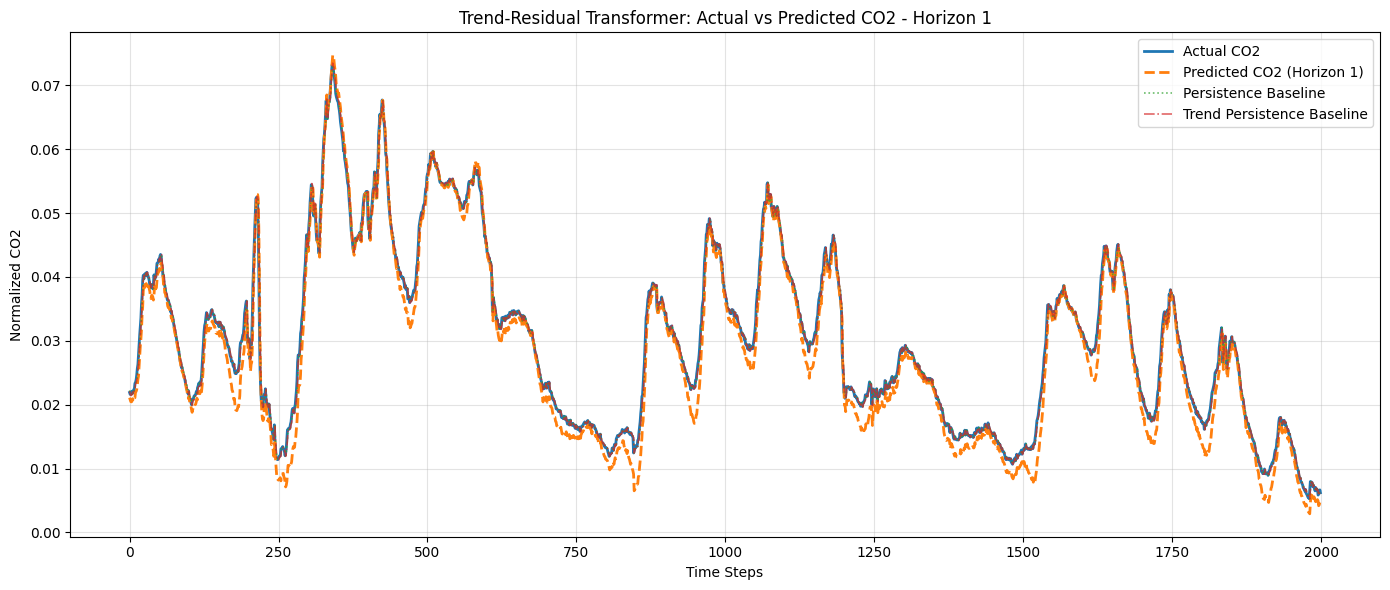

Prediction plot saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/actual_vs_predicted_horizon_1.png


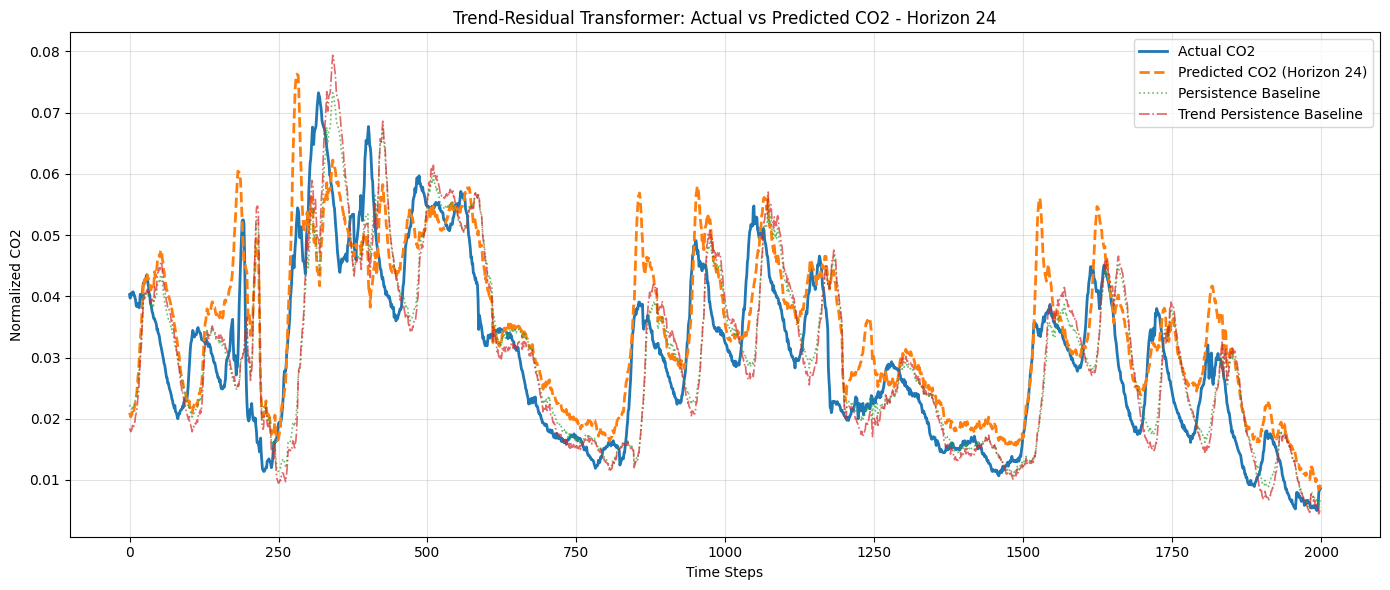

Prediction plot saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/actual_vs_predicted_horizon_24.png


In [27]:
actual_2d = np.asarray(actual)
predictions_2d = np.asarray(predictions)
persistence_2d = np.asarray(persistence_predictions)
trend_persistence_2d = np.asarray(trend_persistence_predictions)


def get_plot_size(plot_size, *arrays):
    available_steps = min(len(array) for array in arrays)

    if plot_size is None:
        return available_steps

    if not isinstance(plot_size, int):
        raise ValueError("PLOT_SIZE must be an integer or None")

    if plot_size <= 0:
        raise ValueError("PLOT_SIZE must be greater than 0, or None for all timesteps")

    return min(plot_size, available_steps)


for horizon_to_compare in [1, OUTPUT_LENGTH]:
    horizon_index = horizon_to_compare - 1
    plot_size = get_plot_size(
        PLOT_SIZE,
        actual_2d,
        predictions_2d,
        persistence_2d,
        trend_persistence_2d,
    )

    plt.figure(figsize=(14, 6))
    plt.plot(
        actual_2d[:plot_size, horizon_index],
        label=f"Actual {target_label}",
        linewidth=2,
    )
    plt.plot(
        predictions_2d[:plot_size, horizon_index],
        label=f"Predicted {target_label} (Horizon {horizon_to_compare})",
        linewidth=2,
        linestyle="--",
    )
    plt.plot(
        persistence_2d[:plot_size, horizon_index],
        label="Persistence Baseline",
        linewidth=1.2,
        linestyle=":",
        alpha=0.7,
    )
    plt.plot(
        trend_persistence_2d[:plot_size, horizon_index],
        label="Trend Persistence Baseline",
        linewidth=1.2,
        linestyle="-.",
        alpha=0.7,
    )
    plt.title(
        f"Trend-Residual Transformer: "
        f"Actual vs Predicted {target_label} - Horizon {horizon_to_compare}"
    )
    plt.xlabel("Time Steps")
    plt.ylabel(f"Normalized {target_label}")
    plt.legend()
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    prediction_plot_path = os.path.join(
        RESULTS_DIR,
        f"actual_vs_predicted_horizon_{horizon_to_compare}.png"
    )
    plt.savefig(prediction_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Prediction plot saved:", prediction_plot_path)


## Training and Validation Loss Visualization

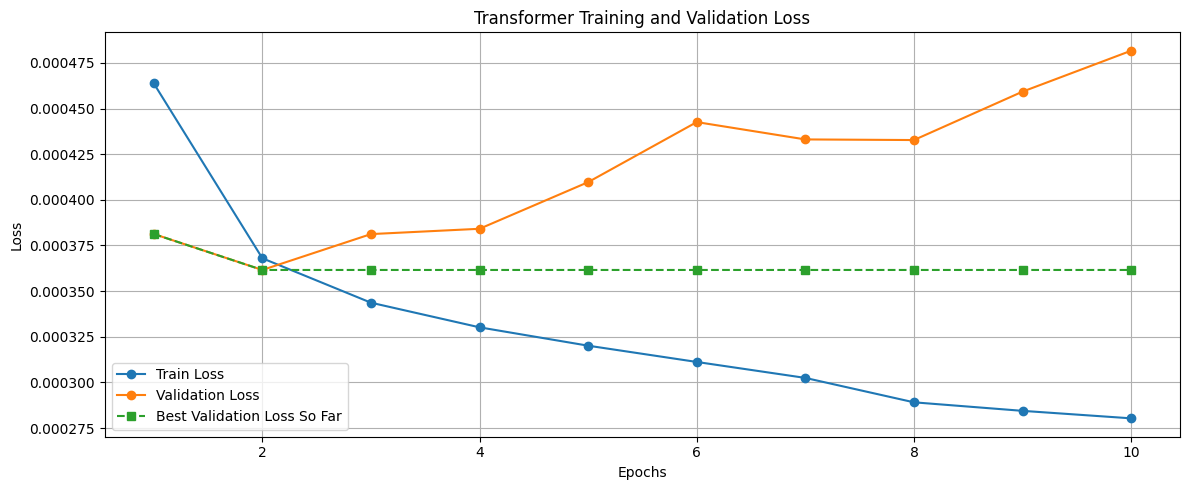

Loss plot saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/training_validation_loss.png


In [28]:
plt.figure(figsize=(12, 5))

epoch_axis = range(1, len(train_losses) + 1)
best_val_losses = np.minimum.accumulate(val_losses)

plt.plot(
    epoch_axis,
    train_losses,
    marker="o",
    label="Train Loss",
)
plt.plot(
    epoch_axis,
    val_losses,
    marker="o",
    label="Validation Loss",
)
plt.plot(
    epoch_axis,
    best_val_losses,
    marker="s",
    linestyle="--",
    label="Best Validation Loss So Far",
)

plt.title("Transformer Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = os.path.join(RESULTS_DIR, "training_validation_loss.png")
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Loss plot saved:", loss_plot_path)


In [29]:
MODEL_PATH = os.path.join(
    RESULTS_DIR,
    f"wavelet_transformer_IL{SEQ_LENGTH}_OL{OUTPUT_LENGTH}.pth"
)
torch.save(model.state_dict(), MODEL_PATH)
print("Model saved:", MODEL_PATH)


Model saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/wavelet_transformer_IL192_OL24.pth


## Explainability: Permutation Feature Importance


In [30]:
def evaluate_loader_rmse(model, loader, max_batches=None):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch_index, (X_batch, y_batch) in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            outputs = model(X_batch.to(device))
            preds.extend(outputs.cpu().numpy())
            trues.extend(y_batch.numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)
    return np.sqrt(mean_squared_error(trues.flatten(), preds.flatten()))


baseline_explainability_rmse = evaluate_loader_rmse(
    model,
    test_loader,
    max_batches=EXPLAINABILITY_BATCHES,
)

feature_importance_rows = []
model.eval()

for feature_index, feature_name in enumerate(model_feature_columns):
    permuted_preds = []
    permuted_trues = []

    with torch.no_grad():
        for batch_index, (X_batch, y_batch) in enumerate(test_loader):
            if batch_index >= EXPLAINABILITY_BATCHES:
                break

            X_permuted = X_batch.clone()
            permutation = torch.randperm(X_permuted.shape[0])
            X_permuted[:, :, feature_index] = X_permuted[permutation, :, feature_index]

            outputs = model(X_permuted.to(device))
            permuted_preds.extend(outputs.cpu().numpy())
            permuted_trues.extend(y_batch.numpy())

    permuted_preds = np.asarray(permuted_preds)
    permuted_trues = np.asarray(permuted_trues)
    permuted_rmse = np.sqrt(
        mean_squared_error(permuted_trues.flatten(), permuted_preds.flatten())
    )

    feature_importance_rows.append({
        "feature": feature_name,
        "baseline_rmse": baseline_explainability_rmse,
        "permuted_rmse": permuted_rmse,
        "rmse_increase": permuted_rmse - baseline_explainability_rmse,
    })

feature_importance_df = pd.DataFrame(feature_importance_rows).sort_values(
    "rmse_increase",
    ascending=False,
).reset_index(drop=True)

feature_importance_path = os.path.join(RESULTS_DIR, "permutation_feature_importance.csv")
feature_importance_df.to_csv(feature_importance_path, index=False)

print("Permutation feature importance saved:", feature_importance_path)
feature_importance_df


Permutation feature importance saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/permutation_feature_importance.csv


,feature,baseline_rmse,permuted_rmse,rmse_increase
0,scd41_co2,0.008787,0.009665,8.780780e-04
1,hour_cos,0.008787,0.009417,6.307855e-04
2,hour_sin,0.008787,0.009050,2.632559e-04
3,ens160_aqi,0.008787,0.008859,7.269976e-05
4,scd41_temperature,0.008787,0.008826,3.949483e-05
5,dayofweek_cos,0.008787,0.008816,2.893825e-05
6,bme688_pressure,0.008787,0.008799,1.195547e-05
7,dayofweek_sin,0.008787,0.008796,9.611167e-06
8,bme688_gas_resistance,0.008787,0.008787,0.000000e+00
9,ens160_tvoc,0.008787,0.008786,-8.384649e-07


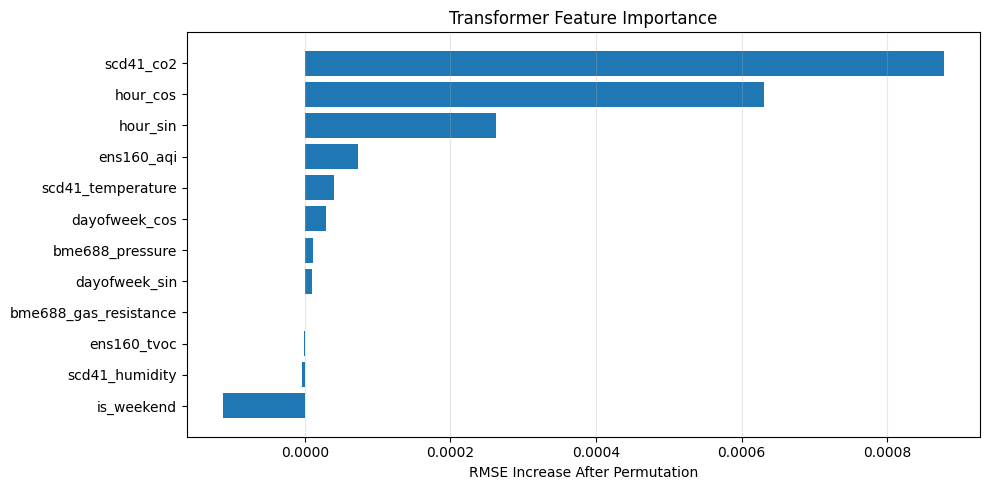

Feature importance plot saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/permutation_feature_importance.png


In [31]:
plt.figure(figsize=(10, 5))
plot_importance = feature_importance_df.head(12).iloc[::-1]
plt.barh(plot_importance["feature"], plot_importance["rmse_increase"])
plt.xlabel("RMSE Increase After Permutation")
plt.title("Transformer Feature Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()

importance_plot_path = os.path.join(RESULTS_DIR, "permutation_feature_importance.png")
plt.savefig(importance_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Feature importance plot saved:", importance_plot_path)


## Uncertainty Quantification: Monte Carlo Dropout


In [32]:
def enable_dropout_layers(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


mc_predictions = []

for run_index in range(MC_DROPOUT_RUNS):
    model.eval()
    enable_dropout_layers(model)
    run_predictions = []

    with torch.no_grad():
        for batch_index, (X_batch, y_batch) in enumerate(test_loader):
            if batch_index >= UNCERTAINTY_BATCHES:
                break
            outputs = model(X_batch.to(device))
            run_predictions.extend(outputs.cpu().numpy())

    mc_predictions.append(np.asarray(run_predictions))

model.eval()
mc_predictions = np.asarray(mc_predictions)
mean_prediction = mc_predictions.mean(axis=0)
std_prediction = mc_predictions.std(axis=0)
lower_bound = np.percentile(mc_predictions, 2.5, axis=0)
upper_bound = np.percentile(mc_predictions, 97.5, axis=0)

np.save(os.path.join(RESULTS_DIR, "mc_dropout_predictions.npy"), mc_predictions)
np.save(os.path.join(RESULTS_DIR, "mc_dropout_mean.npy"), mean_prediction)
np.save(os.path.join(RESULTS_DIR, "mc_dropout_std.npy"), std_prediction)

print("MC dropout predictions shape:", mc_predictions.shape)
print("Uncertainty files saved in:", RESULTS_DIR)


MC dropout predictions shape: (30, 256, 24)
Uncertainty files saved in: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0


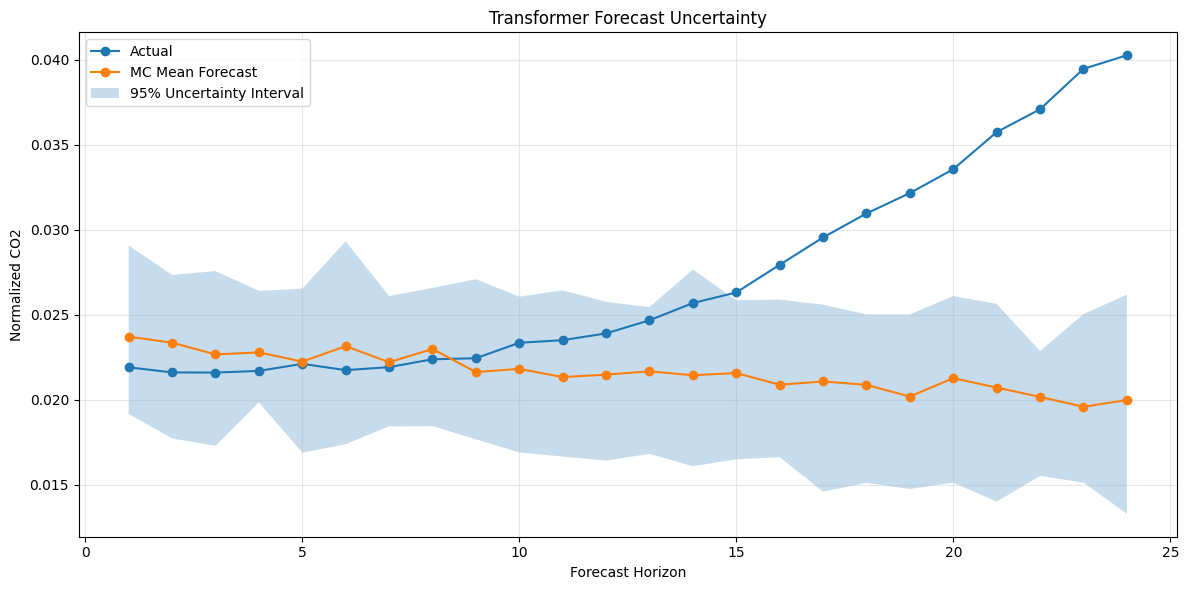

Uncertainty plot saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/mc_dropout_uncertainty.png


In [33]:
uncertainty_sample_index = 0
horizon_axis = np.arange(1, OUTPUT_LENGTH + 1)
actual_uncertainty = actual[uncertainty_sample_index]

plt.figure(figsize=(12, 6))
plt.plot(
    horizon_axis,
    actual_uncertainty,
    marker="o",
    label="Actual",
)
plt.plot(
    horizon_axis,
    mean_prediction[uncertainty_sample_index],
    marker="o",
    label="MC Mean Forecast",
)
plt.fill_between(
    horizon_axis,
    lower_bound[uncertainty_sample_index],
    upper_bound[uncertainty_sample_index],
    alpha=0.25,
    label="95% Uncertainty Interval",
)
plt.title("Transformer Forecast Uncertainty")
plt.xlabel("Forecast Horizon")
plt.ylabel(f"Normalized {target_label}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

uncertainty_plot_path = os.path.join(RESULTS_DIR, "mc_dropout_uncertainty.png")
plt.savefig(uncertainty_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Uncertainty plot saved:", uncertainty_plot_path)


In [34]:
uncertainty_df = pd.DataFrame({
    "forecast_horizon": horizon_axis,
    "actual": actual_uncertainty,
    "mean_prediction": mean_prediction[uncertainty_sample_index],
    "std_dev": std_prediction[uncertainty_sample_index],
    "lower_bound": lower_bound[uncertainty_sample_index],
    "upper_bound": upper_bound[uncertainty_sample_index],
})

uncertainty_summary_path = os.path.join(RESULTS_DIR, "uncertainty_summary_sample.csv")
uncertainty_df.to_csv(uncertainty_summary_path, index=False)
print("Uncertainty summary saved:", uncertainty_summary_path)
uncertainty_df


Uncertainty summary saved: ../../Transformer_Results/Transformer_IL192_OL24_E10_BS32_LR7e-05_DR0.28_GF2_SPLITchronological_by_station_ATTNPOOL_TRENDLOSS_WEND2.6_SWT0_SWJ0_SWQ0_SWF0/uncertainty_summary_sample.csv


,forecast_horizon,actual,mean_prediction,std_dev,lower_bound,upper_bound
0,1,0.021911,0.023714,0.003167,0.019166,0.029082
1,2,0.021612,0.023363,0.002742,0.017725,0.027349
2,3,0.021602,0.022670,0.002887,0.017295,0.027574
3,4,0.021700,0.022791,0.001985,0.019850,0.026411
4,5,0.022116,0.022248,0.002870,0.016888,0.026540
5,6,0.021744,0.023156,0.003263,0.017388,0.029322
6,7,0.021921,0.022210,0.002209,0.018437,0.026104
7,8,0.022384,0.022990,0.002232,0.018451,0.026583
8,9,0.022446,0.021632,0.002725,0.017674,0.027094
9,10,0.023354,0.021820,0.002669,0.016900,0.026067
